# 05. Model Preparation

## 5.1. Постановка задачи

### Задача:
Подготовить корректные данные для прогнозирования плохого отзыва в момент подтверждения заказа — без обучения модели и без использования будущей информации.

- объект наблюдения - один заказ;
- задача - бинарная классификация;
- target - bad_review;
- момент прогноза - после подтверждения заказа;
- bad_review = 1 для оценок 1–2;
- bad_review = 0 для оценок 3–5.

Модель должна использовать только информацию, известную к моменту подтверждения заказа.

## 5.2. Загрузка данных

In [1]:
import pandas as pd
import numpy as np

In [2]:
orders_analytics = pd.read_csv("../data/processed/orders_analytics.csv", parse_dates=["order_purchase_timestamp",
                                                                     "order_approved_at",
                                                                     "order_delivered_carrier_date",
                                                                     "order_delivered_customer_date",
                                                                     "order_estimated_delivery_date",
                                                                     "review_creation_date", 
                                                                     "review_answer_timestamp"])

In [3]:
orders_analytics[["order_purchase_timestamp", 
                  "order_approved_at", 
                  "order_delivered_carrier_date", 
                  "order_delivered_customer_date",
                  "order_estimated_delivery_date",
                  "review_creation_date", 
                  "review_answer_timestamp"]].info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_purchase_timestamp       99441 non-null  datetime64[us]
 1   order_approved_at              99281 non-null  datetime64[us]
 2   order_delivered_carrier_date   97658 non-null  datetime64[us]
 3   order_delivered_customer_date  96476 non-null  datetime64[us]
 4   order_estimated_delivery_date  99441 non-null  datetime64[us]
 5   review_creation_date           98673 non-null  datetime64[us]
 6   review_answer_timestamp        98673 non-null  datetime64[us]
dtypes: datetime64[us](7)
memory usage: 5.3 MB


In [4]:
orders_analytics.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'customer_lat', 'customer_lng', 'items_count',
       'products_count', 'sellers_count', 'categories_count',
       'unknown_category_items', 'total_price', 'mean_item_price',
       'max_item_price', 'total_freight', 'mean_freight', 'total_weight_g',
       'total_volume_cm3', 'has_unknown_category', 'has_multiple_sellers',
       'has_multiple_products', 'order_total', 'freight_ratio',
       'payment_total', 'payments_count', 'payment_types_count',
       'max_installments', 'main_payment_type', 'has_multiple_payment_types',
       'used_installments', 'review_id', 'review_score',
       'review_creation_date', 'review_answer_timestamp', 'has_review_comment',
       'has_review_

In [5]:
orders_analytics["purchase_year_month"].info()

<class 'pandas.Series'>
RangeIndex: 99441 entries, 0 to 99440
Series name: purchase_year_month
Non-Null Count  Dtype
--------------  -----
99441 non-null  str  
dtypes: str(1)
memory usage: 777.0 KB


In [6]:
#восстановление типа для purchase_year_month
orders_analytics["purchase_year_month"] = (
    pd.to_datetime(orders_analytics["purchase_year_month"])
    .dt.to_period("M")
)

In [7]:
orders_analytics["purchase_year_month"].dtype

period[M]

In [8]:
orders_analytics.shape

(99441, 64)

In [9]:
orders_analytics["bad_review"].value_counts()

bad_review
0.0    84179
1.0    14494
Name: count, dtype: int64

In [10]:
orders_analytics.duplicated().sum()

np.int64(0)

## 5.3. Проверка уровня данных

In [11]:
orders_analytics["order_id"].is_unique

True

In [12]:
orders_analytics["order_purchase_timestamp"].min()

Timestamp('2016-09-04 21:15:19')

In [13]:
orders_analytics["order_purchase_timestamp"].max()

Timestamp('2018-10-17 17:30:18')

## 5.4. Создание отдельной metadata-таблицы

In [14]:
metadata_columns = [
    "order_id",
    "customer_id",
    "customer_unique_id",
    "order_purchase_timestamp"
]

metadata = orders_analytics[metadata_columns].copy()

## 5.5. Проверка target

In [15]:
orders_analytics["bad_review"].value_counts(
    normalize=True,
    dropna=False
)

bad_review
0.0    0.846522
1.0    0.145755
NaN    0.007723
Name: proportion, dtype: float64

In [16]:
orders_analytics["order_approved_at"].isna().sum()

np.int64(160)

In [17]:
model_data = (
    orders_analytics
    .dropna(subset=["bad_review", "order_approved_at"])
    .copy()
)

model_data["bad_review"] = model_data["bad_review"].astype(int)

In [18]:
metadata = model_data[metadata_columns].copy()

Модель будет обучаться только на заказах с отзывами. Поэтому результат характеризует риск плохой оценки среди пользователей, оставивших отзыв.

## 5.6. Классификация признаков по моменту доступности

In [19]:
# прямые утечки из отзыва
review_leakage_features = [
    "review_score",
    "review_id",
    "review_creation_date",
    "review_answer_timestamp",
    "has_review_comment",
    "has_review_title",
    "reviews_count",
    "had_multiple_reviews"
]

In [20]:
# Признаки будущей доставки
future_delivery_features = [
    "order_status",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "carrier_handoff_time_days",
    "delivery_time_days",
    "delivery_delay_days",
    "is_late_delivery",
    "delay_days",
    "early_delivery_days",
    "invalid_approval_carrier_order"
]

In [21]:
#Идентификаторы
identifier_features = [
    "order_id",
    "customer_id",
    "customer_unique_id"
]

In [22]:
# Сырые даты
raw_date_features = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_estimated_delivery_date",
    "purchase_year_month"
]

In [23]:
uncertain_payment_features = [
    "payment_total",
    "payments_count",
    "payment_types_count",
    "has_multiple_payment_types",
    "payment_difference",
    "abs_payment_difference"
]

In [24]:
likely_available_payment_features = [
    "max_installments",
    "main_payment_type",
    "used_installments"
]

В датасете отсутствуют временные метки платежей. Предполагается, что выбранный тип оплаты и количество платежных периодов известны к моменту подтверждения заказа. Итоговые платёжные суммы и признаки нескольких платежных операций в первую версию модели не включаются.

In [25]:
target_feature = "bad_review"

In [26]:
#товарные и финансовые признаки
order_features = [
    "items_count",
    "products_count",
    "sellers_count",
    "categories_count",
    "unknown_category_items",
    "total_price",
    "mean_item_price",
    "max_item_price",
    "total_freight",
    "mean_freight",
    "total_weight_g",
    "total_volume_cm3",
    "has_unknown_category",
    "has_multiple_sellers",
    "has_multiple_products",
    "order_total",
    "freight_ratio"
]

In [27]:
# географические признаки
customer_features = [
    "customer_zip_code_prefix",
    "customer_city",
    "customer_state",
    "customer_lat",
    "customer_lng"
]

In [28]:
# календарные признаки
purchase_time_features = [
    "purchase_year",
    "purchase_month",
    "purchase_day_of_week",
    "purchase_hour",
    "purchase_is_weekend"
]

### Вывод

Все признаки были классифицированы с учётом момента прогнозирования — сразу после подтверждения заказа.

Из будущего набора признаков будут исключены:

- `review_leakage_features`;
- `future_delivery_features`;
- `identifier_features`;
- `raw_date_features`.

Платёжные признаки были разделены по предполагаемому моменту доступности. Тип оплаты и количество платежных периодов считаются известными при подтверждении заказа, поэтому `main_payment_type`, `max_installments` и `used_installments` могут быть включены в модель. Итоговые суммы и характеристики нескольких платёжных операций исключаются из первой версии модели, поскольку в датасете отсутствуют временные метки платежей и нельзя достоверно подтвердить их доступность на момент прогноза.

`order_features`,`customer_features`, `purchase_time_features` доступны к моменту подтверждения заказа и могут использоваться моделью. Признак `estimated_delivery_time_days` также допустим, поскольку отражает обещанный, а не фактический срок доставки. Признак `approval_time_days` допустим, так как прогноз выполняется после подтверждения заказа и продолжительность подтверждения к этому моменту уже известна.

Целевая переменная `bad_review` будет храниться отдельно от входных признаков. Таким образом, итоговый набор признаков должен содержать только сведения, которые доступны непосредственно после подтверждения заказа, что позволит избежать использования информации из будущего и получить реалистичную оценку качества модели.

## 5.7. Формирование X и Y

In [29]:
columns_to_drop = (
    review_leakage_features
    + future_delivery_features
    + identifier_features
    + raw_date_features
    + uncertain_payment_features
    + [target_feature]
)

x = model_data.drop(columns=columns_to_drop).copy()
y = model_data[target_feature].copy()

In [30]:
#проверки
assert target_feature not in x.columns
assert len(x) == len(y)
assert x.index.equals(y.index)

In [31]:
x.columns

Index(['customer_zip_code_prefix', 'customer_city', 'customer_state',
       'customer_lat', 'customer_lng', 'items_count', 'products_count',
       'sellers_count', 'categories_count', 'unknown_category_items',
       'total_price', 'mean_item_price', 'max_item_price', 'total_freight',
       'mean_freight', 'total_weight_g', 'total_volume_cm3',
       'has_unknown_category', 'has_multiple_sellers', 'has_multiple_products',
       'order_total', 'freight_ratio', 'max_installments', 'main_payment_type',
       'used_installments', 'purchase_year', 'purchase_month',
       'purchase_day_of_week', 'purchase_hour', 'purchase_is_weekend',
       'approval_time_days', 'estimated_delivery_time_days'],
      dtype='str')

## 5.8. Проверка утечек

In [32]:
suspicious_words = [
    "review",
    "delivered",
    "delay",
    "late",
    "carrier",
    "status",
    "answer"
]

suspicious_columns = [
    column
    for column in x.columns
    if any(
        word in column.lower()
        for word in suspicious_words
    )
]

suspicious_columns

[]

In [33]:
assert target_feature not in x.columns

assert set(
    review_leakage_features
).isdisjoint(x.columns)

assert set(
    future_delivery_features
).isdisjoint(x.columns)

assert set(
    identifier_features
).isdisjoint(x.columns)

assert set(
    uncertain_payment_features
).isdisjoint(x.columns)

## 5.9. Определение типов признаков

In [34]:
categorical_features = x.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numeric_features = x.select_dtypes(
    include=["number"]
).columns.tolist()

boolean_features = x.select_dtypes(
    include=["bool"]
).columns.tolist()

In [35]:
all_selected_features = (
    categorical_features
    + numeric_features
    + boolean_features
)

set(x.columns) - set(all_selected_features)

set()

In [36]:
categorical_features

['customer_city', 'customer_state', 'main_payment_type']

In [37]:
numeric_features

['customer_zip_code_prefix',
 'customer_lat',
 'customer_lng',
 'items_count',
 'products_count',
 'sellers_count',
 'categories_count',
 'unknown_category_items',
 'total_price',
 'mean_item_price',
 'max_item_price',
 'total_freight',
 'mean_freight',
 'total_weight_g',
 'total_volume_cm3',
 'has_unknown_category',
 'has_multiple_sellers',
 'has_multiple_products',
 'order_total',
 'freight_ratio',
 'max_installments',
 'used_installments',
 'purchase_year',
 'purchase_month',
 'purchase_day_of_week',
 'purchase_hour',
 'approval_time_days',
 'estimated_delivery_time_days']

In [38]:
boolean_features

['purchase_is_weekend']

In [39]:
#корректировка типа customer_zip_code_prefix
categorical_features = [
    "customer_zip_code_prefix",
    "customer_city",
    "customer_state",
    "main_payment_type"
]

numeric_features = [
    column
    for column in numeric_features
    if column != "customer_zip_code_prefix"
]

assert "customer_zip_code_prefix" in categorical_features
assert "customer_zip_code_prefix" not in numeric_features

In [40]:
categorical_features_linear = [
    column
    for column in categorical_features
    if column not in [
        "customer_city",
        "customer_zip_code_prefix"
    ]
]

categorical_features_catboost = categorical_features.copy()

In [41]:
#фиксируем особенность календарных признаков
calendar_features = [
    "purchase_month",
    "purchase_day_of_week",
    "purchase_hour"
]

# 5.10. Решение по высококардинальному категориальному признаку customer_city

In [42]:
x[categorical_features].nunique().sort_values(ascending=False)

customer_zip_code_prefix    14973
customer_city                4117
customer_state                 27
main_payment_type               4
dtype: int64

In [43]:
categorical_features_linear = [
    column
    for column in categorical_features
    if column != "customer_city"
]

categorical_features_catboost = categorical_features.copy()

## 5.11. Анализ пропусков без заполнения

In [44]:
missing_table = pd.DataFrame({
    "missing_count": x.isna().sum(),
    "missing_percent": x.isna().mean() * 100
})

missing_table = (
    missing_table
    .loc[
        missing_table["missing_count"] > 0
    ]
    .sort_values(
        "missing_percent",
        ascending=False
    )
)

missing_table

,missing_count,missing_percent
total_volume_cm3,631,0.640492
total_weight_g,631,0.640492
sellers_count,615,0.624251
categories_count,615,0.624251
products_count,615,0.624251
items_count,615,0.624251
has_unknown_category,615,0.624251
has_multiple_sellers,615,0.624251
unknown_category_items,615,0.624251
total_price,615,0.624251


## 5.12. Создание train / validation / test

Распределение количества заказов по времени было исследовано в ноутбуке 04_eda.ipynb. Объём данных постепенно увеличивается и достигает стабильного уровня в 2018 году. Последние месяцы датасета содержат резко уменьшившееся количество заказов и, вероятно, являются неполными, поэтому они не включаются в моделирование.
Для проверки способности модели работать на более новых заказах используется временное разделение. Обучающая выборка содержит наиболее ранние заказы, валидационная — следующие по времени, а тестовая — наиболее поздний полный период.

### 5.12.1. Распределение количества заказов с отзывами по месяцам

In [45]:
monthly_distribution = (
    metadata
    .assign(
        bad_review=y,
        purchase_month=metadata[
            "order_purchase_timestamp"
        ].dt.to_period("M")
    )
    .groupby("purchase_month")
    .agg(
        orders_count=("bad_review", "size"),
        bad_reviews_count=("bad_review", "sum"),
        bad_review_rate=("bad_review", "mean")
    )
)

monthly_distribution

,orders_count,bad_reviews_count,bad_review_rate
purchase_month,,,
2016-09,4,4,1.000000
2016-10,313,87,0.277955
2016-12,1,0,0.000000
2017-01,787,122,0.155019
2017-02,1754,284,0.161916
2017-03,2659,376,0.141407
2017-04,2383,369,0.154847
2017-05,3657,465,0.127153
2017-06,3214,409,0.127256


<Axes: title={'center': 'Количество заказов с отзывами по месяцам'}, xlabel='purchase_month'>

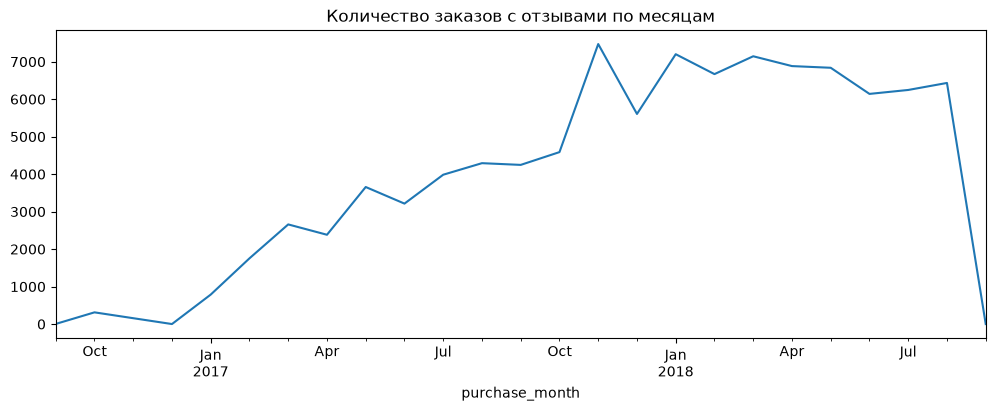

In [46]:
monthly_distribution[
    "orders_count"
].plot(
    figsize=(12, 4),
    title="Количество заказов с отзывами по месяцам"
)

<Axes: title={'center': 'Доля плохих отзывов по месяцам'}, xlabel='purchase_month'>

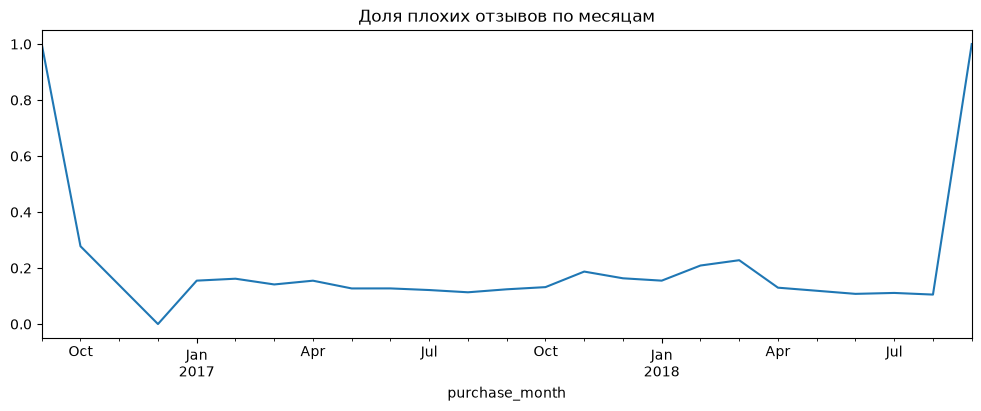

In [47]:
monthly_distribution[
    "bad_review_rate"
].plot(
    figsize=(12, 4),
    title="Доля плохих отзывов по месяцам"
)

### 5.12.2. Фиксация границ 

In [48]:
train_start = pd.Timestamp("2017-01-01")
train_end = pd.Timestamp("2018-01-01")
validation_end = pd.Timestamp("2018-05-01")
test_end = pd.Timestamp("2018-09-01")

### 5.12.3. Создание масок

In [49]:
purchase_date = metadata[
    "order_purchase_timestamp"
]

train_mask = (
    (purchase_date >= train_start)
    & (purchase_date < train_end)
)

validation_mask = (
    (purchase_date >= train_end)
    & (purchase_date < validation_end)
)

test_mask = (
    (purchase_date >= validation_end)
    & (purchase_date < test_end)
)

### 5.12.4. Создание выборок

In [50]:
X_train = x.loc[train_mask].copy()
y_train = y.loc[train_mask].copy()

X_valid = x.loc[validation_mask].copy()
y_valid = y.loc[validation_mask].copy()

X_test = x.loc[test_mask].copy()
y_test = y.loc[test_mask].copy()

In [51]:
metadata_train = metadata.loc[train_mask].copy()
metadata_valid = metadata.loc[validation_mask].copy()
metadata_test = metadata.loc[test_mask].copy()

### 5.12.5. Проверки

In [52]:
#проверка индексов
assert x.index.equals(y.index)
assert x.index.equals(metadata.index)

assert X_train.index.equals(y_train.index)
assert X_valid.index.equals(y_valid.index)
assert X_test.index.equals(y_test.index)

In [53]:
#проверка отсутствия пересечений
assert set(X_train.index).isdisjoint(X_valid.index)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_valid.index).isdisjoint(X_test.index)

In [54]:
#Проверка, что каждый использованный объект попал ровно в одну выборку
used_rows_count = (
    len(X_train)
    + len(X_valid)
    + len(X_test)
)

expected_rows_count = (
    train_mask
    | validation_mask
    | test_mask
).sum()

assert used_rows_count == expected_rows_count

### 5.12.6. Сводная таблица

In [55]:
split_summary = pd.DataFrame({
    "sample": [
        "train",
        "validation",
        "test"
    ],
    "rows": [
        len(X_train),
        len(X_valid),
        len(X_test)
    ],
    "bad_reviews": [
        y_train.sum(),
        y_valid.sum(),
        y_test.sum()
    ],
    "bad_review_rate": [
        y_train.mean(),
        y_valid.mean(),
        y_test.mean()
    ],
    "date_min": [
        metadata_train[
            "order_purchase_timestamp"
        ].min(),
        metadata_valid[
            "order_purchase_timestamp"
        ].min(),
        metadata_test[
            "order_purchase_timestamp"
        ].min()
    ],
    "date_max": [
        metadata_train[
            "order_purchase_timestamp"
        ].max(),
        metadata_valid[
            "order_purchase_timestamp"
        ].max(),
        metadata_test[
            "order_purchase_timestamp"
        ].max()
    ]
})

split_summary["good_reviews"] = [
    (y_train == 0).sum(),
    (y_valid == 0).sum(),
    (y_test == 0).sum()
]

split_summary["sample_share"] = (
    split_summary["rows"]
    / split_summary["rows"].sum()
)

split_summary

split_summary

,sample,rows,bad_reviews,bad_review_rate,date_min,date_max,good_reviews,sample_share
0,train,44644,6444,0.144342,2017-01-05 11:56:06,2017-12-31 23:29:31,38200,0.454628
1,validation,27897,5033,0.180414,2018-01-01 02:48:41,2018-04-30 23:47:26,22864,0.284086
2,test,25658,2846,0.110921,2018-05-01 00:02:11,2018-08-29 15:00:37,22812,0.261286


### 5.12.7. Финальная проверка временного порядка

In [56]:
assert (
    metadata_train["order_purchase_timestamp"].max()
    < metadata_valid["order_purchase_timestamp"].min()
)

assert (
    metadata_valid["order_purchase_timestamp"].max()
    < metadata_test["order_purchase_timestamp"].min()
)

### 5.12.8. Проверка пропусков по выборкам

In [57]:
split_missing_summary = pd.DataFrame({
    "train": X_train.isna().mean() * 100,
    "validation": X_valid.isna().mean() * 100,
    "test": X_test.isna().mean() * 100
})

split_missing_summary = (
    split_missing_summary
    .loc[
        split_missing_summary.max(axis=1) > 0
    ]
    .sort_values(
        "train",
        ascending=False
    )
)

split_missing_summary

,train,validation,test
total_volume_cm3,1.050533,0.362046,0.194871
total_weight_g,1.050533,0.362046,0.194871
items_count,1.014694,0.362046,0.194871
total_freight,1.014694,0.362046,0.194871
max_item_price,1.014694,0.362046,0.194871
products_count,1.014694,0.362046,0.194871
sellers_count,1.014694,0.362046,0.194871
total_price,1.014694,0.362046,0.194871
mean_item_price,1.014694,0.362046,0.194871
categories_count,1.014694,0.362046,0.194871


### 5.12.9. Вывод

Данные были разделены на обучающую, валидационную и тестовую выборки с сохранением хронологического порядка. Модель будет обучаться на заказах с января 2017 года до января 2018 года, настраиваться на заказах с января по апрель 2018 года и проходить финальную проверку на заказах с мая по август 2018 года.
Заказы до января 2017 года исключены из-за крайне малого количества наблюдений и нестабильной доли негативных отзывов. Заказы начиная с сентября 2018 года исключены из-за неполноты последних месяцев датасета. Такое разделение имитирует реальное применение модели: обучение выполняется на прошлых заказах, а качество проверяется на более новых данных.
Перед разделением строки без известного значения bad_review были исключены, поэтому дополнительно проверены количество наблюдений и доля негативных отзывов в каждой выборке. Пересечения между train, validation и test отсутствуют. Заполнение пропусков и кодирование признаков на данном этапе не выполнялись — эти преобразования будут обучаться только на train внутри ML-pipeline.

## 5.13. Сохранение информации

In [58]:
split_labels = pd.Series(
    "excluded",
    index=model_data.index,
    name="split"
)

split_labels.loc[train_mask] = "train"
split_labels.loc[validation_mask] = "validation"
split_labels.loc[test_mask] = "test"

assert x.index.equals(split_labels.index)

In [59]:
#итоговая таблица
ml_dataset = pd.concat(
    [
        metadata,
        x,
        y.rename(target_feature),
        split_labels
    ],
    axis=1
)

In [60]:
assert len(ml_dataset) == len(model_data)

assert ml_dataset.index.equals(
    model_data.index
)

assert ml_dataset["order_id"].is_unique

assert ml_dataset[target_feature].notna().all()

assert ml_dataset["split"].notna().all()

In [61]:
#проверка распределения по выборкам
ml_dataset["split"].value_counts()

split
train         44644
validation    27897
test          25658
excluded        319
Name: count, dtype: int64

In [62]:
ml_dataset.shape

(98518, 38)

In [63]:
#Проверка повторяющихся названий столбцов
ml_dataset.columns[
    ml_dataset.columns.duplicated()
].tolist()

[]

In [64]:
#сохранение
ml_dataset_used = ml_dataset.loc[ml_dataset["split"].isin(["train", "validation", "test"])].copy()

ml_dataset_used.to_csv(
    "../data/processed/ml_dataset.csv",
    index=False
)

## 5.14. Финальная проверка готовности

In [65]:
assert ml_dataset_used.isna().all(axis=1).sum() == 0
assert set(
    ml_dataset_used["split"].unique()
) == {
    "train",
    "validation",
    "test"
}

print(
    "Размер итогового ML-датасета:",
    ml_dataset_used.shape
)

print(
    "Количество признаков:",
    x.shape[1]
)

print(
    ml_dataset_used["split"].value_counts()
)

Размер итогового ML-датасета: (98199, 38)
Количество признаков: 32
split
train         44644
validation    27897
test          25658
Name: count, dtype: int64
